# 👉 Урок 9 & 10. Архитектура Transformer, работа с LLM и промптами

## 🎯 Цели урока

- понять ограничения RNN и LSTM;
- изучить полную архитектуру Transformer;
- разобраться в работе Encoder и Decoder;
- понять механизм Self-Attention;
- изучить Query, Key и Value;
- разобраться в Multi-Head Attention;
- понять роль Feed Forward Network, Residual Connections и Layer Normalization;
- проследить полный путь от эмбеддинга до генерации следующего токена в GPT.

---

Автор курса: Логинов Дмитрий Владимирович, преподаватель и методист МШП.


# 📜 Часть 1. Почему появился Transformer?

До 2017 года основными архитектурами для обработки текста были RNN, LSTM и GRU.

## Главная идея RNN

Нейросеть получает последовательность токенов по одному и обновляет скрытое состояние:

```text
h₁ = RNN(x₁)
h₂ = RNN(x₂, h₁)
h₃ = RNN(x₃, h₂)
...
```

### Определение

**Скрытое состояние (Hidden State)** — вектор, содержащий информацию обо всех ранее обработанных токенах.

### Проблема длинного контекста

Информация должна пройти через десятки или сотни шагов вычислений.
При этом важные сведения постепенно теряются.

Даже LSTM не смогли полностью решить эту проблему.

### Вторая проблема

RNN невозможно эффективно распараллелить:

```text
Токен 1 → Токен 2 → Токен 3 → ...
```

Каждый следующий шаг зависит от предыдущего.

Для современных GPU это крайне неэффективно.

### Вывод

Требовалась архитектура, которая:

- видит всю последовательность сразу;
- хорошо работает с длинным контекстом;
- масштабируется на большие вычислительные кластеры.


# 🏗️ Часть 2. Общая архитектура Transformer

В статье *Attention Is All You Need* была предложена архитектура Transformer.

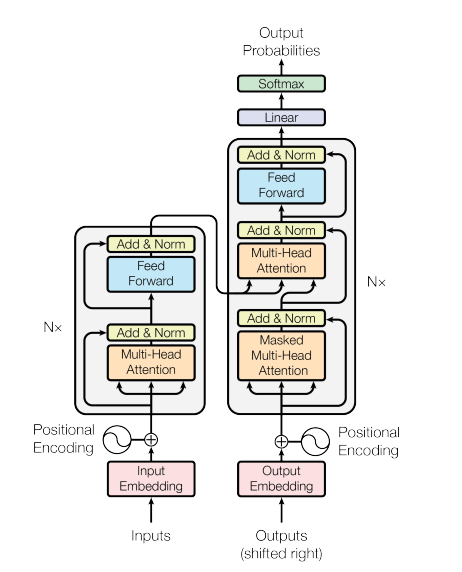

Полная схема состоит из двух крупных компонентов:

```text
Encoder
↓
Decoder
```

## Encoder

Получает входную последовательность и строит её контекстное представление.

Задача Encoder:

- анализ текста;
- поиск зависимостей;
- формирование информативных признаков.

## Decoder

Использует результаты Encoder и генерирует выходную последовательность.

### Пример

В задаче перевода:

```text
Вход:  I love machine learning
Выход: Я люблю машинное обучение
```

Encoder анализирует английский текст.
Decoder генерирует русский перевод.

### Важно

GPT использует только Decoder-часть архитектуры.
Именно поэтому GPT относят к классу Decoder-only Transformer.


# 🔢 Часть 3. Вход Transformer

Предположим, что этап токенизации и построения эмбеддингов уже выполнен.

На вход поступает матрица:

```text
X ∈ R^(n × d)
```

где:

- n — количество токенов;
- d — размерность эмбеддинга.

Например:

```text
n = 100 токенов
d = 768
```

Тогда вход имеет размер:

```text
100 × 768
```

Каждая строка соответствует одному токену.

## Что знает модель на этом этапе?

Модель знает только значения эмбеддингов.

Она ещё не понимает:

- порядок слов;
- грамматические связи;
- смысловые зависимости.


# 📍 Часть 4. Positional Encoding

Transformer обрабатывает все токены одновременно.

Поэтому архитектура не знает порядок слов автоматически.

Для решения этой проблемы используется Positional Encoding.

### Определение

**Positional Encoding** — дополнительный вектор, содержащий информацию о позиции токена в последовательности.

Итоговый вход:

```text
Z = Embedding + Position
```

После сложения модель получает информацию:

- какой токен первый;
- какой второй;
- какой десятый;
- на каком расстоянии находятся токены друг от друга.

Без Positional Encoding предложения

```text
Кот укусил собаку
Собака укусила кота
```

были бы практически неразличимы.


# 🎯 Часть 5. Self-Attention

Self-Attention — центральный механизм Transformer.

### Определение

Self-Attention позволяет каждому токену определить,
какие другие токены наиболее важны для понимания его контекста.

Вместо последовательного чтения текста модель строит связи между всеми токенами одновременно.

Результатом становится матрица взаимодействий между токенами.

Именно здесь возникает понимание контекста, местоимений, зависимостей и смысловых связей.


# 🔍 Часть 6. Query, Key и Value

Чтобы механизм Attention мог работать, каждый входной токен преобразуется в три новых представления:

- Query (Запрос)
- Key (Ключ)
- Value (Значение)

## Что такое Query?

### Определение

**Query** — вектор, описывающий информацию, которую токен хочет найти в других токенах последовательности.

Можно представить Query как вопрос, который токен задаёт окружающим словам.

Например, если модель анализирует местоимение:

`он`

то Query может содержать информацию, необходимую для поиска объекта, к которому относится это местоимение.

## Что такое Key?

### Определение

**Key** — вектор, описывающий информацию, которой обладает токен.

Каждый токен как бы сообщает другим токенам:

> Вот какую информацию я могу предоставить.

Во время вычисления внимания Query одного токена сравнивается с Key остальных токенов.

Чем лучше совпадение, тем сильнее оказывается связь между токенами.

## Что такое Value?

### Определение

**Value** — информация, которая будет передана дальше после вычисления внимания.

Если токен оказался важным для других токенов, именно его Value попадёт в итоговое представление последовательности.

## Как Query, Key и Value работают вместе?

Схема выглядит следующим образом:

```text
Токен
 ↓
Query
Key
Value
```

Затем Query одного токена сравнивается с Key остальных токенов.

После этого механизм внимания определяет, какие Value необходимо использовать сильнее, а какие слабее.

Таким образом каждый токен получает информацию от наиболее важных соседей.

## Почему это важно?

Благодаря разделению на Query, Key и Value модель может самостоятельно определять:

- какие слова связаны между собой;
- какие части текста наиболее важны;
- какие зависимости необходимо учитывать при генерации ответа.

# 👁️ Часть 7. Attention Head

На первый взгляд может показаться, что одного механизма внимания достаточно.

На практике это не так.

В одном и том же предложении одновременно существуют различные виды зависимостей.

Например:

```text
Исследователь представил новую модель,
которая показала высокую точность.
```

Для правильного понимания текста модели необходимо одновременно определить:

- кто выполнил действие;
- к чему относится местоимение;
- какие слова образуют грамматическую конструкцию;
- какие слова связаны по смыслу.

Одному механизму внимания сложно отслеживать все типы связей одновременно.

### Определение

**Attention Head** — отдельный независимый механизм внимания внутри Transformer.

Каждая голова внимания анализирует текст по-своему.

## Что изучают разные головы?

В процессе обучения разные головы начинают специализироваться на различных типах зависимостей.

Например:

**Head №1**

Отслеживает грамматические связи.

**Head №2**

Следит за местоимениями.

**Head №3**

Находит причинно-следственные отношения.

**Head №4**

Выявляет смысловые связи между объектами.

## Почему это полезно?

Каждая голова получает собственное представление текста.

В результате модель смотрит на один и тот же текст сразу с нескольких точек зрения.

Это позволяет строить гораздо более качественное понимание контекста.

# 🧠 Часть 8. Multi-Head Attention

Теперь возникает вопрос: что делать с результатами работы всех голов внимания?

Для этого используется механизм Multi-Head Attention.

## Определение

**Multi-Head Attention** — блок Transformer, объединяющий результаты нескольких независимых Attention Head.

## Схема работы

```text
Head 1   Head 2   Head 3   Head 4
   ↓        ↓        ↓        ↓
   ← Объединение результатов →
              ↓
   Новое представление текста
```

## Почему нельзя использовать только одну голову?

Если используется одна голова внимания:
- модель анализирует текст одним способом.

Если используется несколько голов:
- модель анализирует текст сразу с нескольких сторон.

Это позволяет учитывать:
- грамматику;
- структуру предложения;
- смысловые зависимости;
- логические связи.

## Результат работы Multi-Head Attention

После объединения результатов каждая позиция получает более богатое представление контекста.

Это представление передаётся дальше в следующий блок Transformer.

# 🏗️ Часть 9. Encoder Layer

Теперь соберём все изученные элементы вместе.

Каждый слой Encoder состоит из нескольких последовательных блоков.

## Шаг 1. Multi-Head Attention

Токены обмениваются информацией друг с другом.

После этого каждый токен начинает учитывать контекст всей последовательности.

## Шаг 2. Residual Connection

К результату работы Attention добавляется исходный вход.

Это позволяет сохранить важную информацию.

## Шаг 3. Layer Normalization

Полученные значения нормализуются.

Это делает обучение более стабильным.

## Шаг 4. Feed Forward Network

Каждый токен независимо проходит через небольшую нейронную сеть.

Она преобразует признаки и выделяет более сложные закономерности.

## Шаг 5. Повторная нормализация

После Feed Forward Network снова выполняется нормализация.

## Полная схема Encoder Layer

```text
Вход
  ↓
Multi-Head Attention
  ↓
Add & Norm
  ↓
Feed Forward Network
  ↓
Add & Norm
  ↓
Выход
```

Обычно Transformer содержит не один Encoder Layer, а целый стек таких слоёв.

# 🏗️ Часть 10. Decoder Layer

Decoder во многом похож на Encoder.

Однако его главная задача отличается.

Если Encoder анализирует текст, то Decoder генерирует новый текст.

Поэтому в Decoder появляются дополнительные механизмы.

## Блок 1. Masked Self-Attention

Позволяет учитывать уже известную часть текста.

При этом будущие токены скрываются.

## Блок 2. Cross-Attention

Используется только в полном Transformer.

Позволяет Decoder обращаться к результатам работы Encoder.

Например:

```text
Английский текст
       ↓
   Encoder
       ↓
   Decoder
       ↓
Русский перевод
```

## Блок 3. Feed Forward Network

Преобразует признаки и подготавливает данные для следующего слоя.

## Полная схема Decoder Layer

```text
Вход
  ↓
Masked Self-Attention
  ↓
Add & Norm
  ↓
Cross-Attention
  ↓
Add & Norm
  ↓
Feed Forward Network
  ↓
Add & Norm
  ↓
Выход
```

Именно Decoder лежит в основе моделей семейства GPT.

# 🚫 Часть 11. Masked Self-Attention

При генерации текста модель должна предсказывать следующий токен.

Поэтому ей запрещено видеть будущее.

## Почему это необходимо?

Представим предложение:

```text
Искусственный интеллект активно используется ...
```

Модель должна предсказать следующее слово.

Если она сможет увидеть правильный ответ заранее, обучение потеряет смысл.

## Что делает маска?

Маска скрывает все будущие позиции.

Для каждого токена доступны только уже известные токены.

## Пример

Для последовательности из четырёх токенов:

```text
Токен 1   Токен 2   Токен 3   Токен 4
```

видимость выглядит так:

```text
Токен 1 → видит только себя
Токен 2 → видит 1 и 2
Токен 3 → видит 1, 2 и 3
Токен 4 → видит 1, 2, 3 и 4
```

## Что это даёт?

Модель учится предсказывать следующий токен честно, используя только уже известный контекст.

Именно поэтому GPT способна последовательно генерировать текст слева направо.

# 🔄 Часть 12. Residual Connections и Layer Normalization

Современные Transformer могут содержать десятки и даже сотни слоёв.

Для обучения таких глубоких сетей используются специальные механизмы.

## Residual Connection

### Определение

**Residual Connection** — соединение, которое добавляет вход блока к его выходу.

Схема:

```text
Вход
  ↓
Attention
  ↓
  + ← Вход
  ↓
Выход
```

### Зачем это нужно?

Без Residual Connection информация постепенно теряется.

Чем глубже сеть, тем сильнее эта проблема.

Остаточные связи помогают сохранять важные признаки на протяжении всей сети.

## Layer Normalization

### Определение

**Layer Normalization** — метод нормализации признаков внутри слоя нейронной сети.

### Зачем она нужна?

Во время обучения значения могут становиться:
- слишком большими;
- слишком маленькими;
- нестабильными.

Layer Normalization приводит их к удобному диапазону.

### Преимущества

- стабильное обучение;
- более быстрая сходимость;
- улучшение качества модели.

## Почему эти механизмы используются вместе?

Практически каждый блок Transformer устроен следующим образом:

```text
Attention
    ↓
Residual Connection
    ↓
Layer Normalization
    ↓
Feed Forward Network
    ↓
Residual Connection
    ↓
Layer Normalization
```

Именно такая структура используется в GPT, Claude, Gemini и большинстве современных больших языковых моделей.

# ⚙️ Часть 13. Feed Forward Network

После завершения механизма внимания работа Transformer не заканчивается.

Полученные представления необходимо дополнительно обработать.

Для этого используется Feed Forward Network.

## Определение

**Feed Forward Network (FFN)** — небольшая полносвязная нейронная сеть, применяемая отдельно к каждому токену.

## Что делает FFN?

Если Attention отвечает за обмен информацией между токенами, то FFN отвечает за обработку признаков внутри каждого токена.

Можно сказать, что:

```text
Attention → Собирает информацию
FFN → Преобразует информацию
```

## Почему FFN необходим?

После внимания токен уже знает контекст.

Теперь модели необходимо:
- выделить полезные признаки;
- отбросить лишнюю информацию;
- сформировать более качественное представление текста.

Эту задачу и решает Feed Forward Network.

## Итоговая структура слоя Transformer

```text
Multi-Head Attention
    ↓
Residual Connection
    ↓
Layer Normalization
    ↓
Feed Forward Network
    ↓
Residual Connection
    ↓
Layer Normalization
```

Практически весь Transformer состоит из многократного повторения этой конструкции.

# 🎯 Часть 14. Введение в промптинг

Теперь, когда мы понимаем, как работают LLM изнутри, перейдём к практическому аспекту их использования.

## Что такое промпт?

### Определение

**Промпт (Prompt)** — текст, который пользователь передаёт модели для получения ответа.

Качество ответа напрямую зависит от качества промпта.

## Почему техники промптинга важны?

LLM не читают мысли пользователя.

Они интерпретируют только то, что написано в промпте.

Плохо составленный промпт может привести к:

- неполным или неточным ответам;
- генерации нерелевантного контента;
- появлению галлюцинаций;
- бесполезным или опасным советам.

## Что такое галлюцинации?

### Определение

**Галлюцинации** — это фактологически неверные или вымышленные утверждения, которые модель генерирует как факты.

Галлюцинации возникают, когда модель не знает правильного ответа, но пытается его выдумать.

Хороший промпт снижает вероятность галлюцинаций.

## Основные принципы хорошего промпта

1. **Чёткость** — формулируйте задачу без двусмысленностей.
2. **Конкретика** — указывайте детали, формат, контекст.
3. **Роль** — задавайте модели роль эксперта.
4. **Контекст** — предоставляйте достаточно информации.
5. **Ограничения** — указывайте запреты и предпочтения.

Далее мы разберём конкретные техники промптинга.

# 🧩 Часть 15. Zero-shot, One-shot и Few-shot промптинг

В зависимости от того, сколько примеров мы даём модели, выделяют несколько подходов.

## Zero-shot (Нулевой выстрел)

### Определение

**Zero-shot** — модель получает только инструкцию без примеров.

### Пример

```text
Промпт:
Определи тональность этого отзыва: "Этот фильм был потрясающим!"

Ответ:
Положительная
```

### Когда использовать

- Когда задача простая и очевидная;
- Когда модель уже знакома с форматом;
- Когда нет возможности привести примеры.

## One-shot (Один выстрел)

### Определение

**One-shot** — модель получает инструкцию и один пример выполнения.

### Пример

```text
Промпт:
Определи тональность отзыва.

Пример:
"Этот фильм был ужасным!" → Отрицательная

Теперь определи для:
"Этот фильм был потрясающим!" →

Ответ:
Положительная
```

### Когда использовать

- Когда задача нестандартная;
- Когда нужен конкретный формат ответа;
- Когда модель может неправильно понять задачу.

## Few-shot (Несколько выстрелов)

### Определение

**Few-shot** — модель получает инструкцию и несколько примеров выполнения.

### Пример

```text
Промпт:
Определи тональность отзыва.

Примеры:
"Этот фильм был ужасным!" → Отрицательная
"Средний фильм, ничего особенного." → Нейтральная
"Этот фильм был потрясающим!" → Положительная

Теперь определи для:
"Фильм оставил приятное впечатление" →

Ответ:
Положительная
```

### Когда использовать

- Когда задача сложная и требует много примеров;
- Когда формат ответа должен быть строго определён;
- Когда нужно показать модель поведения.

## Сравнение подходов

| Подход | Количество примеров | Когда использовать |
|--------|---------------------|-------------------|
| Zero-shot | 0 | Простые задачи |
| One-shot | 1 | Нестандартные форматы |
| Few-shot | 2-5+ | Сложные задачи, форматирование |

# 🧠 Часть 16. Chain-of-Thought (CoT)

**Chain-of-Thought (CoT)** — техника, при которой модель просят рассуждать вслух, показывая ход своих мыслей.

## Определение

**Chain-of-Thought** — метод промптинга, при котором модель разбивает сложную задачу на промежуточные шаги и демонстрирует логику решения.

## Почему это работает?

LLM обучались на текстах, где авторы рассуждают и объясняют свои выводы.

Когда модель проговаривает рассуждения, она активирует те же паттерны, которые использовала при обучении.

Это особенно полезно для:

- математических задач;
- логических рассуждений;
- задач, требующих анализа;
- принятия решений.

## Пример

### Без CoT:

```text
Промпт:
У Маши было 15 яблок. Она отдала 7 яблок Пете, потом купила ещё 5.
Сколько яблок у Маши сейчас?

Ответ:
13
```

### С CoT:

```text
Промпт:
У Маши было 15 яблок. Она отдала 7 яблок Пете, потом купила ещё 5.
Сколько яблок у Маши сейчас? Покажи свои рассуждения.

Ответ:
1. У Маши было 15 яблок.
2. Она отдала 7: 15 - 7 = 8
3. Она купила 5: 8 + 5 = 13
Ответ: 13 яблок.
```

## Zero-shot CoT

Можно попросить модель рассуждать без примеров, просто добавив фразу:

```text
"Давай подумаем шаг за шагом"
"Покажи свои рассуждения"
"Объясни, как ты пришёл к этому выводу"
```

## Few-shot CoT

Можно привести примеры рассуждений для сложных задач.

```text
Пример 1:
Вопрос: В корзине было 10 яблок. 3 съели. Сколько осталось?
Рассуждение: Было 10, съели 3, значит 10 - 3 = 7. Ответ: 7.

Вопрос: ... (ваш вопрос)
```

# 🧩 Часть 17. Другие техники промптинга

## 1. Role Prompting (Назначение роли)

### Определение

**Role Prompting** — техника, при которой модель получает определённую роль или профессию.

### Пример

```text
Ты — опытный юрист. Клиент пришёл к тебе за консультацией.
Объясни ему простыми словами, что такое договор оферты.
```

### Почему это работает?

Модель начинает генерировать текст в стиле выбранной роли.

Это влияет на:
- лексику;
- стиль;
- глубину объяснения;
- примеры.

## 2. Constraint Prompting (Ограничения)

### Определение

**Constraint Prompting** — техника, при которой модель ограничивают определёнными правилами.

### Пример

```text
Напиши реферат на тему "Искусственный интеллект".
Ограничения:
- не более 500 слов;
- без технических терминов;
- используй примеры из жизни;
- структура: введение, 2 аргумента, заключение.
```

## 3. Context Prompting (Контекстный промптинг)

### Определение

**Context Prompting** — техника, при которой модели предоставляют дополнительный контекст перед вопросом.

### Пример

```text
Контекст:
Наша компания занимается разработкой мобильных приложений.
У нас 50 сотрудников, офис в Москве, клиенты в России и СНГ.

Вопрос:
Какие технологии нам стоит использовать для нового проекта?
```

### RAG (Retrieval-Augmented Generation)

Это продвинутая форма контекстного промптинга, где контекст извлекается из базы знаний.

## 4. Iterative Prompting (Итеративный промптинг)

### Определение

**Iterative Prompting** — техника, при которой пользователь уточняет и дополняет запросы на основе предыдущих ответов.

### Пример

```text
Шаг 1: Напиши план статьи о машинном обучении.
Шаг 2: Раскрой первый пункт плана.
Шаг 3: Добавь примеры к этому пункту.
Шаг 4: Сделай выводы.
```

## 5. Negative Prompting (Отрицательный промптинг)

### Определение

**Negative Prompting** — техника, при которой указывают, чего модель должна избегать.

### Пример

```text
Напиши рекламный текст для нового смартфона.
Избегай:
- слишком технических терминов;
- сравнений с другими брендами;
- клише и шаблонных фраз.
```

# 🌐 Часть 18. Работа с API LLM

Для интеграции LLM в приложения используются API.

## Что такое API?

### Определение

**API (Application Programming Interface)** — интерфейс, позволяющий программам обмениваться данными с моделью по сети.

## Основные провайдеры API

| Провайдер | Модели | Особенности |
|-----------|--------|-------------|
| OpenAI | GPT-4, GPT-3.5 | Самая популярная, большое сообщество |
| Hugging Face | Сотни моделей | Бесплатные open-source модели |
| Anthropic | Claude | Сильная в аналитике и безопасности |
| Google | Gemini | Интеграция с экосистемой Google |
| Yandex | YandexGPT | Российская модель, есть бесплатный тариф |

## Подготовка к работе

Для работы с большинством API потребуется:

1. Зарегистрироваться на сайте провайдера;
2. Получить API-ключ (токен);
3. Установить библиотеку для работы с API;
4. Настроить подключение.

## Основные параметры запроса

| Параметр | Описание |
|----------|----------|
| model | Название модели |
| messages | Список сообщений (роль + текст) |
| temperature | Степень случайности (0-1/2) |
| max_tokens | Максимальная длина ответа |
| top_p | Альтернативный способ контроля случайности |
| n | Количество вариантов ответа |

## Как работает temperature?

**temperature** контролирует, насколько модель готова выбирать не самые вероятные токены.

```text
temperature = 0     → почти детерминированный ответ (выбирается самый вероятный токен)
temperature = 0.5   → сбалансированный
temperature = 1.0   → креативный, разнообразный
temperature > 1.0   → очень случайный, может быть бессмысленным
```

## Примеры использования

In [2]:
# Установка библиотеки:
!pip install openai

import openai

# Настройка клиента для OpenRouter
client = openai.OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="",
)

# Отправка запроса
response = client.chat.completions.create(
    model="openrouter/free",
    messages=[
        {"role": "system", "content": "Ты — полезный ассистент."},
        {"role": "user", "content": "Что такое машинное обучение?"}
    ],
    temperature=0.7,
    max_tokens=200,
    # Дополнительные параметры OpenRouter (опционально):
    # headers={
    #     "HTTP-Referer": "http://localhost:3000",  # URL вашего приложения
    #     "X-Title": "My App",  # Название вашего приложения
    # }
)

# Вывод ответа
print(response.choices[0].message.content)

**Машинное обучение (МО, machine learning)** — это раздел искусственного интеллекта (ИИ), который занимается разработкой алгоритмов и моделей, способных получать знания и делать прогнозы или принимать решения, опираясь на данные, а не на заранее запрограммированные правила.

Ключевые аспекты машинного обучения:

| Показатель | Что это |
|------------|---------|
| **Цель** | Позволить системе «учиться» из примеров, чтобы улучшать свою работу без явного вмешательства человека. |
| **Как это работает** | Алгоритм анализирует набор обучающих данных, выявляет закономерности, строит математическую модель (например, регрессию, решающую деревья, нейронные сети) и применяет её к новым, ранее не виденным данным. |
| **Типы обучения** | • **Супервизированное** (с метками) – модель обучается на паре «пример → правильный ответ». <br>• **Независимое** (без меток) – модель ищет структуры в данных (кластеризация, понижение размерности). <br>• **Подкрепляющее** (reinforcement learning) – агент учится, 

In [ ]:
# 🔧 Пример 2: Hugging Face API

# Установка библиотеки:
# !pip install huggingface_hub

from huggingface_hub import InferenceClient

# Инициализация клиента
client = InferenceClient(
    model="mistralai/Mistral-7B-Instruct-v0.1",
    token="ваш_token_huggingface"  # Замените на реальный токен
)

# Отправка запроса
response = client.text_generation(
    "<s>[INST] Что такое нейронные сети? [/INST]",
    max_new_tokens=200,
    temperature=0.7
)

print(response)

In [ ]:
# 🔧 Пример 3: Сохранение контекста диалога

# Важно сохранять историю сообщений для поддержания контекста

import openai

openai.api_key = "ваш_api_ключ"

# История диалога
messages = [
    {"role": "system", "content": "Ты — эксперт по Python."},
    {"role": "user", "content": "Что такое декораторы?"},
    {"role": "assistant", "content": "Декораторы — это функции, которые модифицируют другие функции..."},
    {"role": "user", "content": "Приведи пример использования"}
]

response = openai.ChatCompletion.create(
    model="gpt-3.5-turbo",
    messages=messages,
    temperature=0.7
)

print(response.choices[0].message.content)

# Добавляем ответ в историю
messages.append({"role": "assistant", "content": response.choices[0].message.content})

In [ ]:
# 🔧 Пример 4: Использование temperature

import openai

openai.api_key = "ваш_api_ключ"

prompt = "Придумай название для стартапа в сфере AI"

# Низкая температура (консервативно)
response_low = openai.ChatCompletion.create(
    model="gpt-3.5-turbo",
    messages=[{"role": "user", "content": prompt}],
    temperature=0.2
)
print(f"Temperature 0.2: {response_low.choices[0].message.content}")

# Высокая температура (креативно)
response_high = openai.ChatCompletion.create(
    model="gpt-3.5-turbo",
    messages=[{"role": "user", "content": prompt}],
    temperature=1.2
)
print(f"Temperature 1.2: {response_high.choices[0].message.content}")

In [ ]:
# 🔧 Пример 5: Обработка ошибок при работе с API

import openai
import time

openai.api_key = "ваш_api_ключ"

def safe_request(prompt, max_retries=3):
    """Функция с повторными попытками при ошибках"""
    for attempt in range(max_retries):
        try:
            response = openai.ChatCompletion.create(
                model="gpt-3.5-turbo",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.7,
                max_tokens=100
            )
            return response.choices[0].message.content
        except openai.error.RateLimitError:
            print(f"Попытка {attempt+1}: Превышен лимит запросов. Ждём...")
            time.sleep(5)
        except openai.error.APIError as e:
            print(f"Ошибка API: {e}")
            break
        except Exception as e:
            print(f"Неизвестная ошибка: {e}")
            break
    return None

# Пример использования
result = safe_request("Расскажи коротко о Python")
if result:
    print(result)

# 📊 Часть 19. Практические рекомендации

## Как выбрать модель?

| Задача | Рекомендуемая модель |
|--------|----------------------|
| Простые вопросы, быстрые ответы | GPT-3.5-turbo |
| Сложный анализ, генерация кода | GPT-4, Claude |
| Работа на русском языке | YandexGPT, GPT-4 |
| Бесплатные проекты | Hugging Face (Mistral, Llama) |
| Мультимодальные задачи (текст + изображения) | GPT-4V, Gemini |

## Как управлять стоимостью?

1. Используйте `max_tokens` для ограничения длины ответа;
2. Используйте более дешёвые модели для простых задач;
3. Кешируйте частые запросы;
4. Используйте batch-запросы, если возможно;
5. Отслеживайте расход токенов.

## Как оценить качество ответа?

1. Проверьте, отвечает ли ответ на вопрос;
2. Проверьте, нет ли галлюцинаций;
3. Проверьте стиль и форматирование;
4. При необходимости уточните запрос.

## Типичные ошибки при работе с API

1. **Неправильный формат запроса** — проверьте документацию;
2. **Истёкший API-ключ** — обновите ключ;
3. **Превышение лимитов** — используйте retry;
4. **Слишком большой контекст** — обрезайте историю;
5. **Неверный параметр temperature** — используйте от 0 до 2.

## Безопасность

1. Никогда не публикуйте API-ключи в открытом доступе;
2. Используйте переменные окружения для хранения ключей;
3. Ограничивайте доступ к API;
4. Мониторьте использование.

## Где взять API-ключи?

- OpenAI: https://platform.openai.com/api-keys
- Hugging Face: https://huggingface.co/settings/tokens
- Google: https://makersuite.google.com/app/apikey
- Yandex: https://cloud.yandex.ru/services/yandexgpt
- Anthropic: https://console.anthropic.com/settings/keys

In [ ]:
# 🔧 Пример 6: Использование переменных окружения для API-ключа

# Это безопасный способ хранения ключей

import os
import openai

# Загружаем ключ из переменных окружения
# Для этого нужно создать файл .env или установить переменную через терминал:
# export OPENAI_API_KEY="ваш_ключ"

openai.api_key = os.getenv("OPENAI_API_KEY")

if openai.api_key:
    response = openai.ChatCompletion.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": "Hello, AI!"}],
        max_tokens=50
    )
    print(response.choices[0].message.content)
else:
    print("API-ключ не найден. Установите переменную OPENAI_API_KEY.")